In [2]:
import gzip
import random
import re
import math
import textwrap
from pathlib import Path
from collections import Counter, defaultdict
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import duckdb
import sklearn
from sklearn.decomposition import NMF

import psutil

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from link_channels_helper import add_merged_category, category_stats_multi
from IPython.display import Image, display


base = "~/Desktop/from_old_notebook/adaproject/ADA_P3/"

## From Indie to Industry: Growth of YouTube Uploads (2008–2018)

<img src="images/Growth of YouTube.png" width="700">

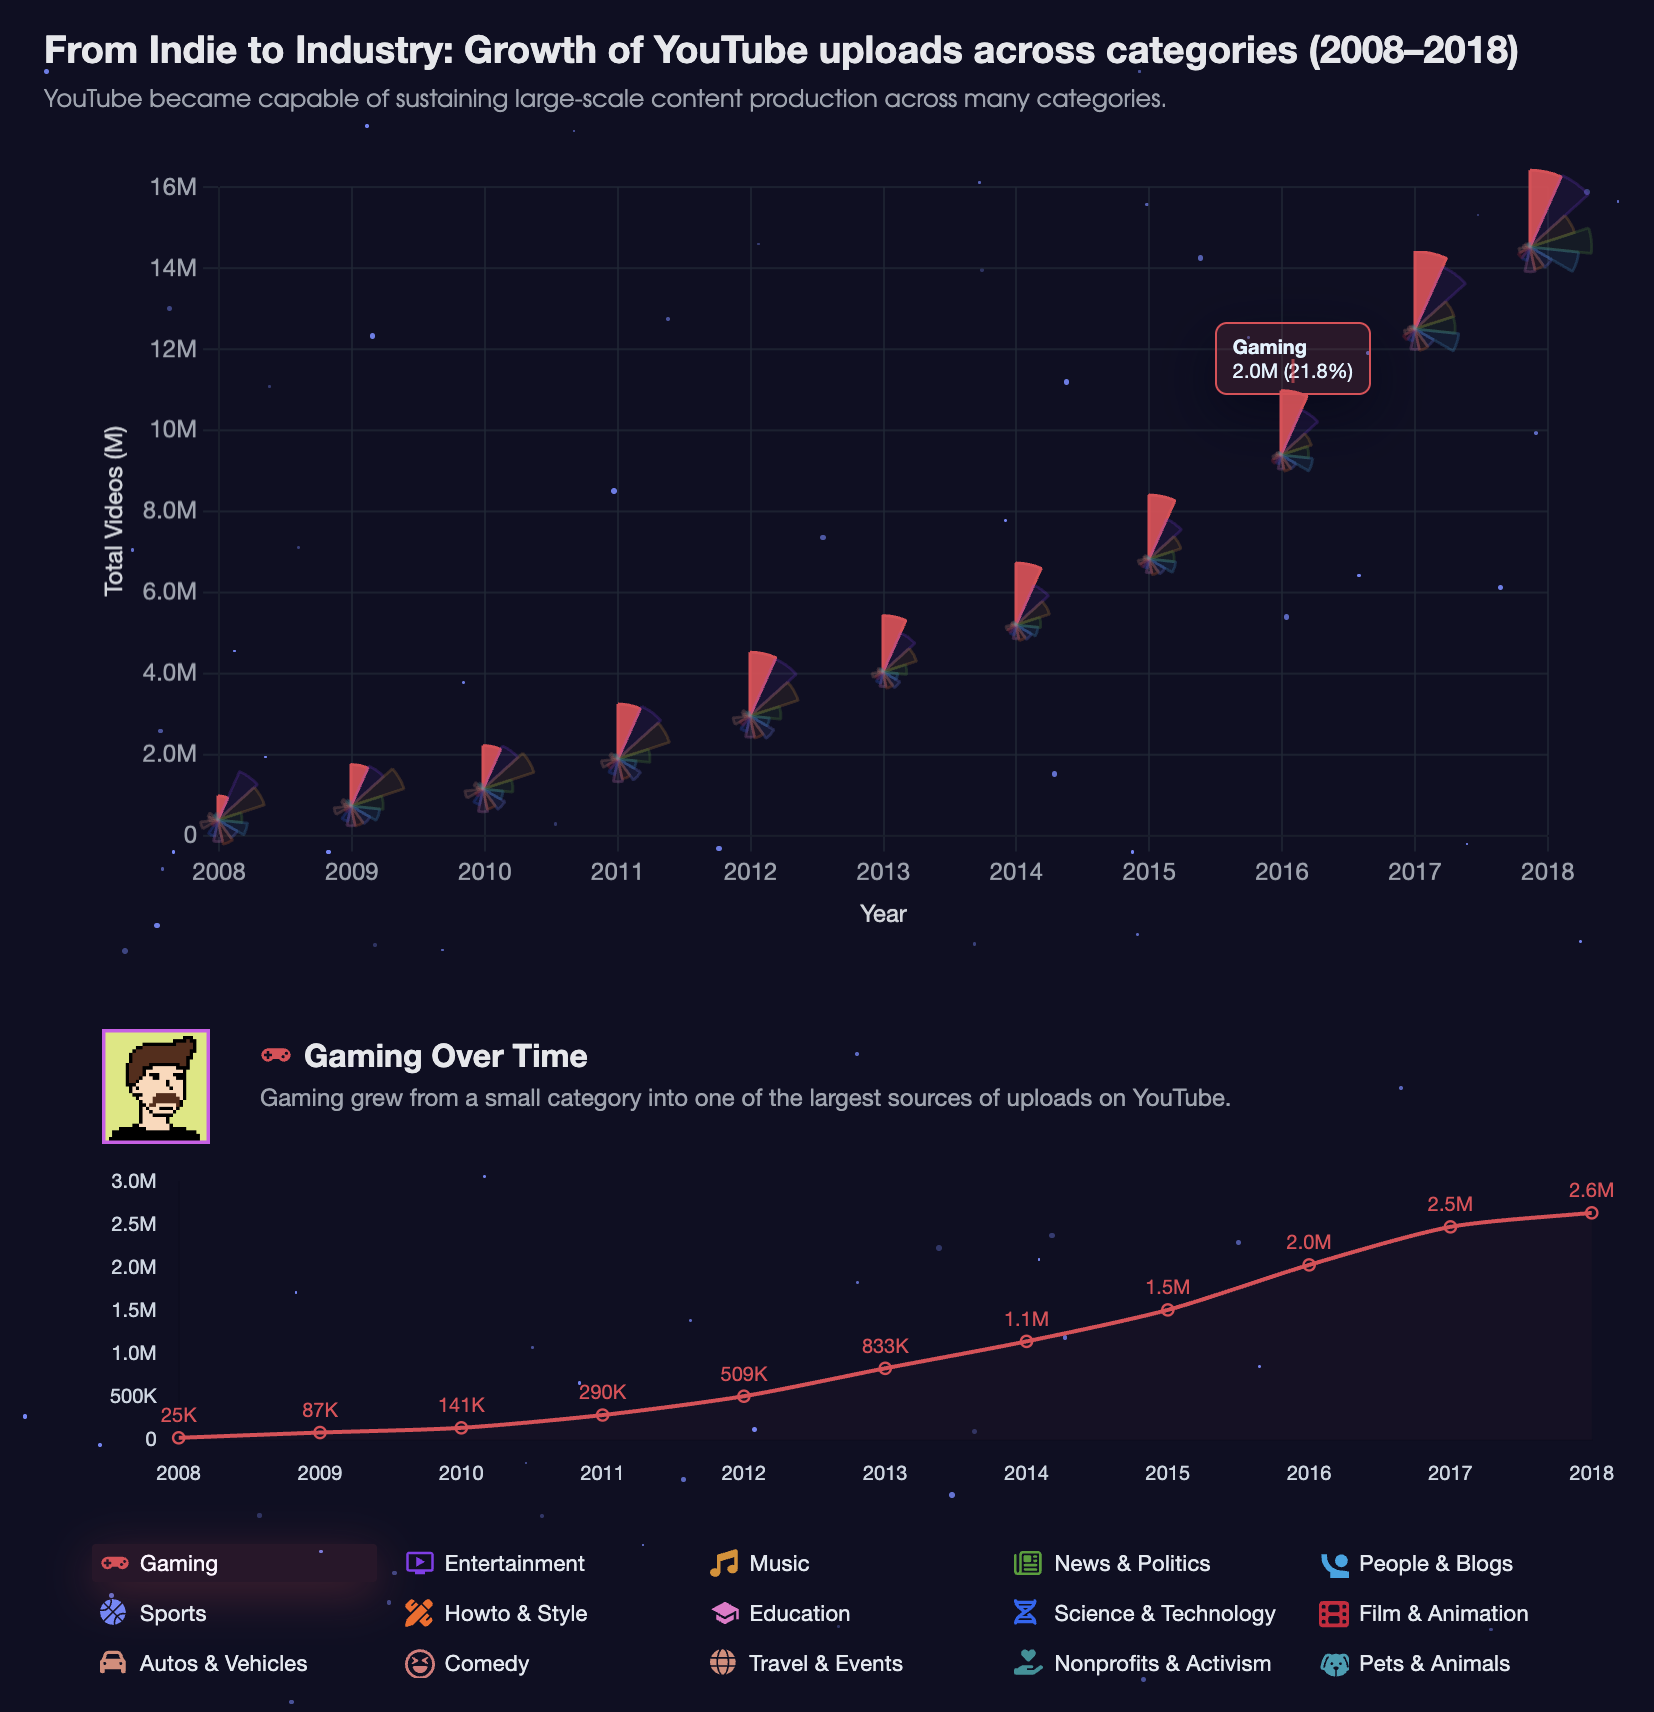

In [4]:
display(Image(filename="images/Growth of YouTube.png"))

**Figure 1.** Growth in the number of YouTube uploads across categories between 2008 and 2018.

## How Creators Learned to Use Links on YouTube
<img src="images/How creators learned to use links on YouTube.png" width="700">


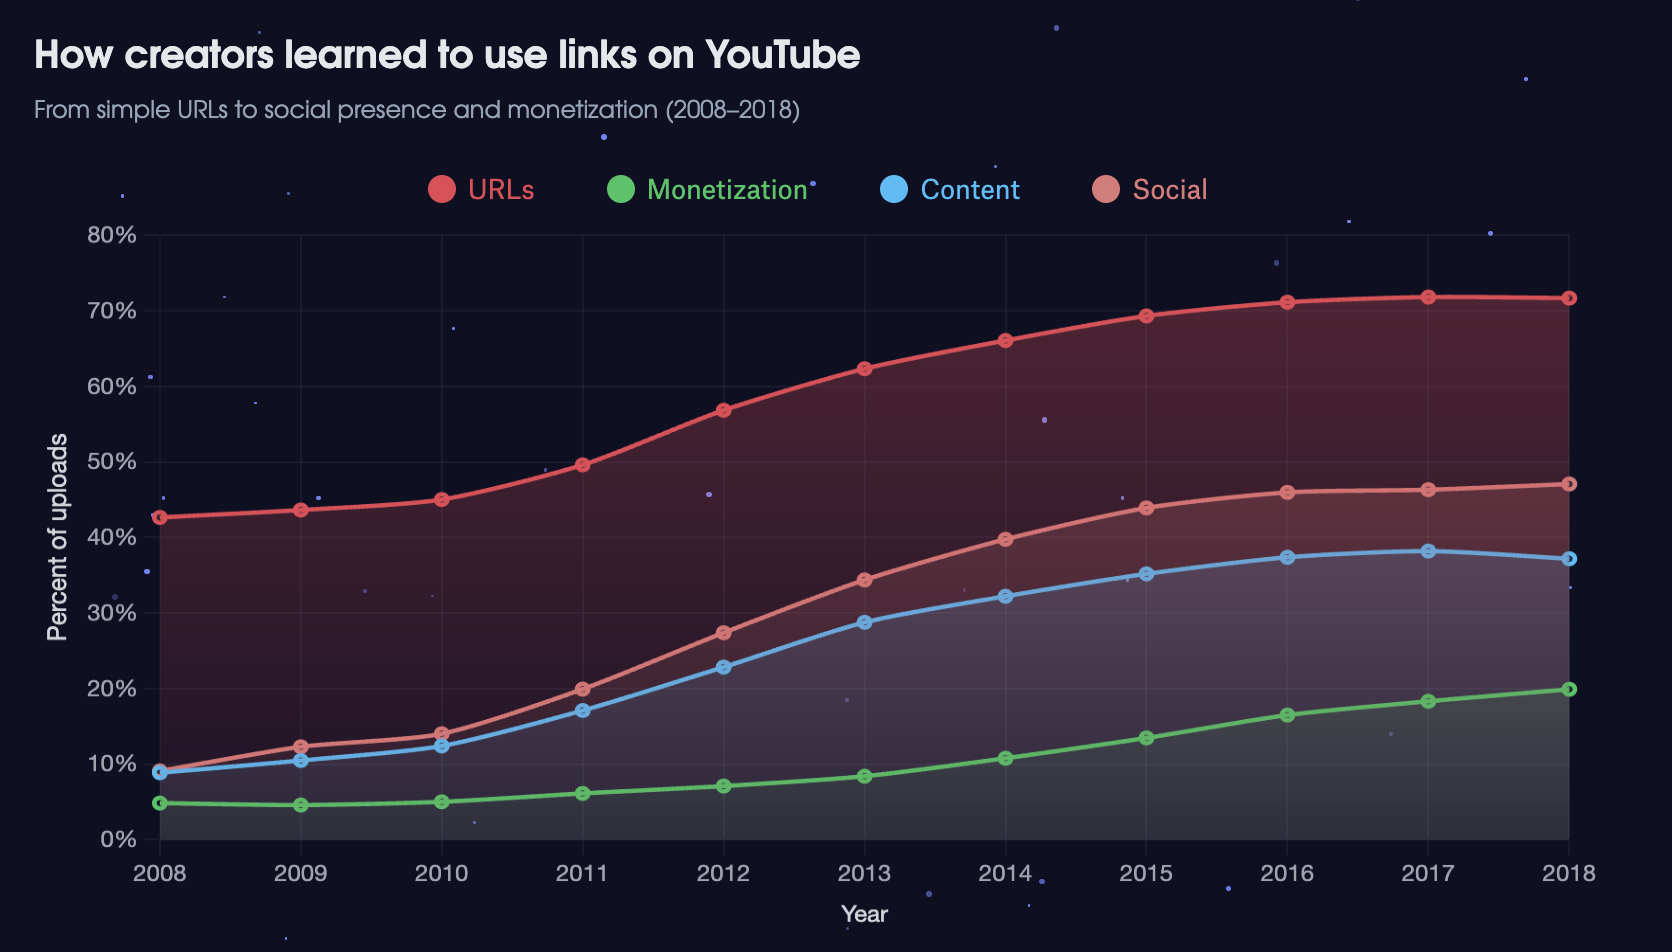

In [5]:
display(Image(filename="images/How creators learned to use links on YouTube.png"))

**Figure 2.** Share of videos containing at least one external link over time.

## How Creators Learned to Use Links Across YouTube Categories

<img src="images/How creators learned to use links across YouTube categories.png" width="700">


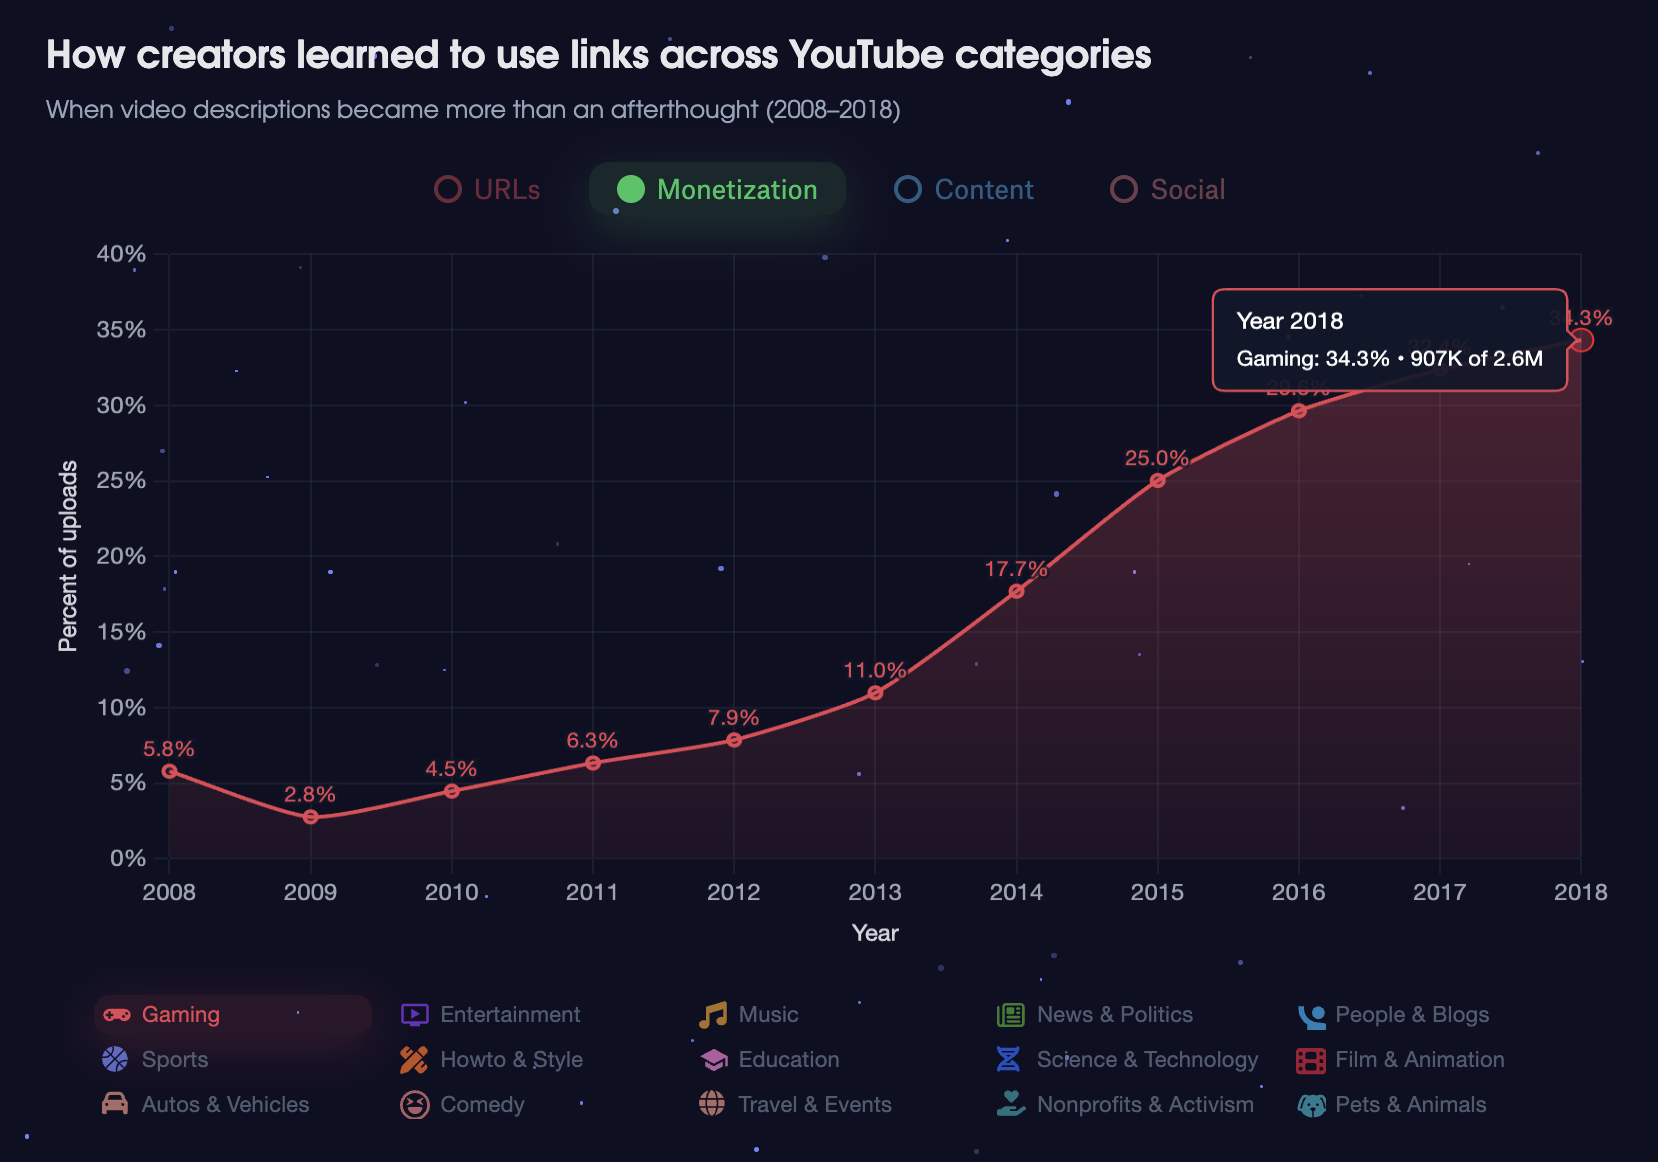

In [6]:
display(Image(filename="images/How creators learned to use links across YouTube categories.png"))

**Figure 3.** Evolution of link usage over time, shown separately for each YouTube category.


## Compare Link Usage Across Categories

<img src="images/Compare link usage across categories.png" width="700">


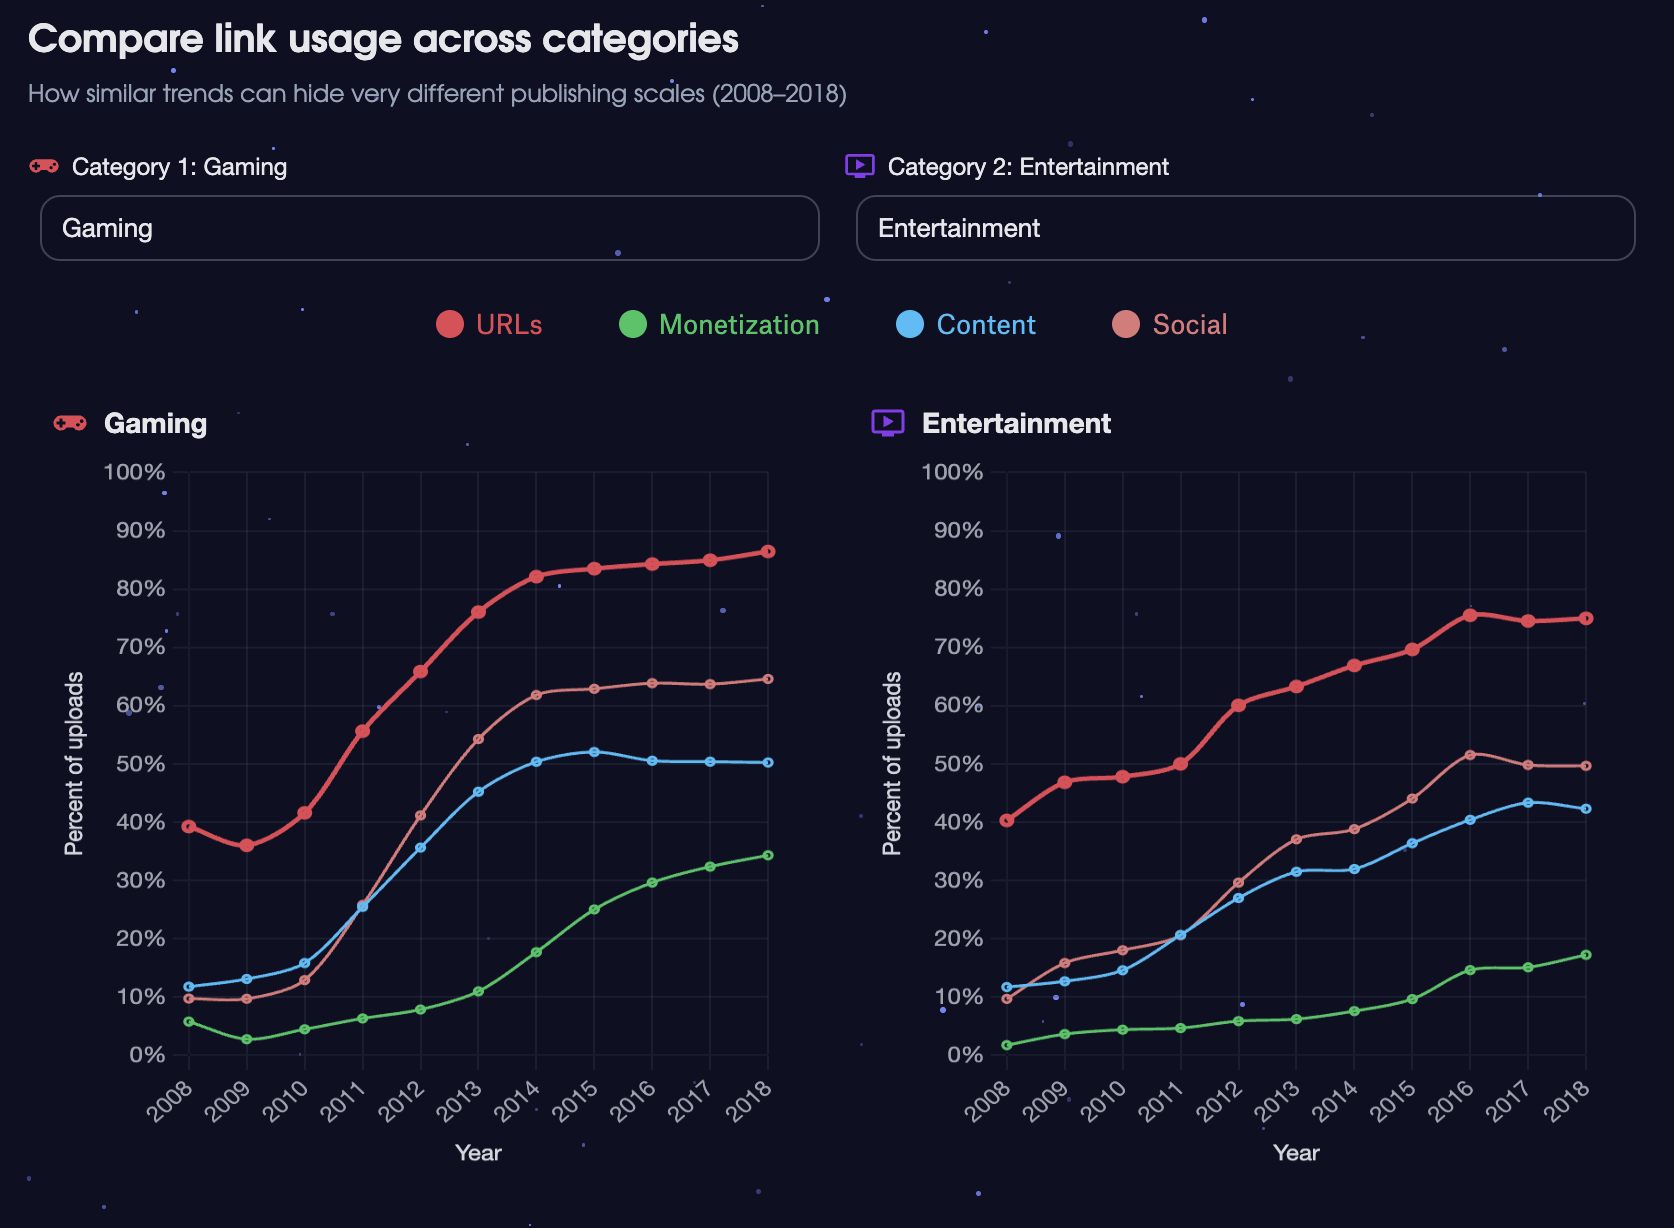

In [8]:
display(Image(filename="images/Compare link usage across categories.png"))

**Figure 4.** Cross-category comparison of link usage rates in a given year.

# Data Preparation and Variable Definitions  
## From Indie to Industry: YouTube Growth and Link Adoption (2008–2018)

This section documents how the datasets behind the following plots were prepared:

1. From Indie to Industry: Growth of YouTube uploads across categories (2008–2018)  
2. How creators learned to use links on YouTube  
3. How creators learned to use links across YouTube categories  
4. Compare link usage across categories

The goal is to describe the **inputs, transformations, and resulting variables** used in the analysis, without interpreting the results. 

## 1. Data Sources

### 1.1 YouTube video metadata (YouNiverse)

The primary dataset contains metadata for YouTube videos and is used to track upload volume and category membership.

**File**
- `yt_metadata_en.jsonl.gz`
- YouTube video metadata is sourced from the **YouNiverse dataset**  
([documentation](https://github.com/epfl-dlab/YouNiverse?tab=readme-ov-file#video-metadata)).

**Relevant fields**
- `display_id`: unique video identifier  
- `upload_date`: upload timestamp  
- `categories`: YouTube category label (e.g., *Music*, *Education*, *Gaming*)

This dataset is the backbone for:
- computing yearly upload counts
- assigning each video to a YouTube category
- joining videos with extracted URLs


### 1.2 Extracted URLs from video descriptions

URLs found in video descriptions are stored in a separate file and linked to videos via `display_id`.

**File**
- `urls.jsonl.gz`

**Notes**
- videos with no URLs appear with missing (`NULL`) URL fields after the join
- URLs may include shortened and unshortened domains

This dataset is used to detect:
- whether a video contains any external link
- which *types* of links appear in the description


### 1.3 Domain taxonomy for link classification

A curated list of domains is used to classify URLs into meaningful link types.

**File**
- `sponsoreddomains_unshortened_checkpoint.csv`

**Fields**
- `domain`: domain name (e.g., `youtube.com`, `amzn.to`)  
- `count`: frequency of appearance in the corpus  
- `category`: fine-grained domain category  

Example entries:

| domain       | count  | category                 |
|-------------|--------|--------------------------|
| youtube.com | 804545 | content/video            |
| twitter.com | 343423 | social_media             |
| amzn.to     | 170338 | monetization/affiliates  |

This file provides the mapping between raw URLs and conceptual link categories.


## 2. Upload Growth Data  
### From Indie to Industry (2008–2018)

### Objective
Construct a dataset that measures how the number of uploaded videos evolved over time across YouTube categories.

### Preparation steps

1. Video metadata is read from `yt_metadata_en.jsonl.gz`.
2. The calendar year is extracted from `upload_date`.
3. The dataset is restricted to uploads between **2008 and 2018**.
4. Videos are grouped by:
   - `year`
   - `yt_category`
5. The total number of uploads is counted per group.

### Output table

The resulting table contains:

| year | yt_category        | uploads |
|------|--------------------|---------|
| 2008 | Travel & Events    | 11 130  |
| 2009 | Travel & Events    | 21 174  |
| 2010 | Travel & Events    | 31 476  |
| 2011 | Travel & Events    | 45 701  |
| 2012 | Travel & Events    | 67 591  |
| 2013 | Travel & Events    | 83 874  |

Each row represents the number of videos uploaded in a given year for a given YouTube category.  
This table is used directly to plot category-level upload growth over time.


## 3. Link Categories (Conceptual Definition)

Links extracted from video descriptions are grouped into three high-level types:

- **Monetization links**  
  Domains associated with revenue generation, such as affiliate links, merchandise stores, sponsored content, or crowdfunding platforms (e.g., `amzn.to`, `amazon.com`, `patreon.com`).

- **Social links**  
  Links pointing to external social media platforms, such as Twitter, Instagram, or Facebook, used to connect a creator’s YouTube presence to other social networks.

- **Content links**  
  Links referencing content-hosting platforms, primarily YouTube URLs, used to promote creators’ own channels, previous videos, or related content.

These categories define the link types tracked in the subsequent analysis and plots.

## 4. Domain Category Merging

The original domain taxonomy contains many fine-grained labels.  
For analysis and visualization, these labels are merged into a smaller set of categories.

### Merged domain groups

- **monetization**: affiliates, stores, courses, merch, sponsors, direct sales  
- **content**: video, music, portfolio hosting platforms  
- **social**: social media platforms  
- **entertainment**: gaming and entertainment services  
- **infrastructure**: URL shorteners, utilities, legal/reference sites  
- **news**: news and media outlets  
- **other**: unknown, invalid, or uncategorized domains

Each domain in the taxonomy is assigned to one of these merged groups. Domains that cannot be mapped are labeled as `other`.


## 5. Video-Level Link Indicators

### Objective
Determine, for each video, whether it contains links of different types.

### Steps

1. Video metadata is left-joined with the URL dataset using `display_id`.
2. For each video, a set of boolean indicators is constructed:
   - `has_urls`: at least one URL appears in the description
   - `has_monetization`: at least one monetization-domain URL appears
   - `has_social`: at least one social-domain URL appears
   - `has_content`: at least one content-domain URL appears
   - `has_entertainment`: at least one entertainment-domain URL appears
   - `has_infrastructure`: at least one infrastructure-domain URL appears
   - `has_news`: at least one news-domain URL appears
3. Domain matching is performed by checking whether any known domain string appears in the URL field.

This produces a per-video representation linking upload year, category, and link usage.

## 6. Yearly Aggregation by Category

For each combination of:

- `year`
- `yt_category`

the following quantities are computed:

- `videos_total`: total number of videos
- `videos_with_urls`
- `videos_with_monetization`
- `videos_with_social`
- `videos_with_content`
- `videos_with_entertainment`
- `videos_with_infrastructure`
- `videos_with_news`

These are raw counts of videos exhibiting each property.

## 7. Normalization to Percentages

To allow comparison across categories with different upload volumes, all link counts are normalized.

For each link type:

\[
\text{percentage} = \frac{\text{videos with link type}}{\text{videos total}} \times 100
\]

This yields variables such as:
- `videos_with_urls_pct`
- `videos_with_monetization_pct`
- `videos_with_social_pct`
- `videos_with_content_pct`

## 8. Reshaping for Visualization

For plotting, the dataset is reshaped into a long (tidy) format with:

- `year`
- `yt_category`
- `metric` (link type)
- `value_pct` (percentage)

This format supports:
- time-series plots of link adoption
- comparisons across YouTube categories
- snapshot comparisons for a single year

## Final Plot-Ready Dataset (Export Format)

To support visualization and external reuse, the processed statistics are exported in a lightweight **record-oriented JSON format**. Each record corresponds to one **YouTube category–year** observation.

### Structure

Each JSON object contains:

- **Temporal dimension**
  - `year`: calendar year of upload activity

- **Category**
  - `yt_category`: YouTube content category

- **Volume**
  - `videos_total`: total number of videos uploaded in that category and year

- **Link usage (counts)**
  - `videos_with_urls`
  - `videos_with_monetization`
  - `videos_with_content`
  - `videos_with_social`
  - `videos_with_entertainment`
  - `videos_with_infrastructure`
  - `videos_with_news`

- **Link usage (percentages)**
  - `videos_with_urls_pct`
  - `videos_with_monetization_pct`
  - `videos_with_content_pct`
  - `videos_with_social_pct`
  - `videos_with_entertainment_pct`
  - `videos_with_infrastructure_pct`
  - `videos_with_news_pct`

Percentages are computed relative to `videos_total`, allowing meaningful comparisons across categories with very different upload volumes.


### Key data files

- [`yt_stats_2008_2018.csv`](data/yt_stats_2008_2018.csv)  
  Year × YouTube category aggregates (upload volume, link counts, and link percentages).

- [`all_videos_links_numbers_v2.csv`](data/all_videos_links_numbers_v2.csv)  
  Global link-usage aggregates across videos (overall time trends).

- [`sponsoreddomains_unshortened_checkpoint.csv`](data/sponsoreddomains_unshortened_checkpoint.csv)  
  Domain taxonomy used to classify links into buckets.

- [`urls.jsonl.gz`](data/urls.jsonl.gz)  
  Extracted URLs per video (keyed by `display_id`) used to compute link indicators.

- [`yt_stats_2008_2018.json`](data/yt_stats_2008_2018.json)  
Record-oriented JSON file containing year × YouTube category aggregates used in the analysis.

### Example Record

```json
{
  "year": 2008,
  "videos_total": 11130,
  "videos_with_urls": 3679,
  "videos_with_monetization": 621,
  "videos_with_content": 734,
  "videos_with_social": 657,
  "videos_with_entertainment": 2,
  "videos_with_infrastructure": 543,
  "videos_with_news": 147,
  "yt_category": "Travel & Events",
  "videos_with_urls_pct": 33.05,
  "videos_with_monetization_pct": 5.58,
  "videos_with_content_pct": 6.59,
  "videos_with_social_pct": 5.90,
  "videos_with_entertainment_pct": 0.02,
  "videos_with_infrastructure_pct": 4.88,
  "videos_with_news_pct": 1.32
}



In [2]:
meta_path = "data/yt_metadata_en.jsonl.gz"
urls_path = "data/urls.jsonl.gz"  
domains_df = pd.read_csv("data/sponsoreddomains_unshortened_checkpoint.csv")

In [3]:
domains_df.head()

,domain,count,category
0,youtube.com,804545,content/video
1,twitter.com,343423,social_media
2,facebook.com,266377,social_media
3,instagram.com,194672,social_media
4,amzn.to,170338,monetization/affiliates


In [4]:
domains_df.category.value_counts()

category
monetization/stores        211
other                      208
unsure                     197
content/video              161
url_shorteners             137
content/music              125
news                        95
social_media                88
gaming                      79
entertainement              79
legal/reference             54
utils                       49
monetization/courses        47
monetization/affiliates     41
monetization/merch          35
content/portfolios          29
monetization/direct         19
monetization/sponsors       11
non-existing site            1
Name: count, dtype: int64

In [5]:
domains_df = add_merged_category(domains_df)

In [6]:
domains_df['merged_category'].value_counts()

merged_category
other             406
monetization      364
content           315
infrastructure    240
entertainment     158
news               95
social             88
Name: count, dtype: int64

### Computing Yearly Link Statistics Across Categories

The following step applies the category-level aggregation function to all YouTube categories in the dataset and collects the resulting yearly statistics into a single table.


In [7]:
meta_path = "data/yt_metadata_en.jsonl.gz"

yt_categories = duckdb.query(f"""
    SELECT DISTINCT categories
    FROM read_json_auto('{meta_path}', format='newline_delimited')
    ORDER BY categories
""").df()["categories"].tolist()

yt_categories


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

['',
 'Autos & Vehicles',
 'Comedy',
 'Education',
 'Entertainment',
 'Film & Animation',
 'Gaming',
 'Howto & Style',
 'Movies',
 'Music',
 'News & Politics',
 'Nonprofits & Activism',
 'People & Blogs',
 'Pets & Animals',
 'Science & Technology',
 'Shows',
 'Sports',
 'Travel & Events']

In [8]:
RUN_FULL_COMPUTATION = False  # set to True to recompute from the raw data

if RUN_FULL_COMPUTATION:
    all_year_dfs = []
    for cat in yt_categories:
        df_year = category_stats_multi(
            meta_path=meta_path,
            urls_path=urls_path,
            yt_category=cat,
            domains_df=domains_df,
        )
        df_year["yt_category"] = cat
        all_year_dfs.append(df_year)
else:
    df_calculated = pd.read_csv("data/all_videos_links_numbers_v2.csv")
    df_calculated.head()

*Note:* In the original execution, a delay was introduced between categories to manage long-running DuckDB queries.  
This delay is omitted here for clarity.


### Category-Level Link Statistics (Result)

The yearly link statistics computed by `category_stats_multi` are stored as a CSV file to avoid recomputing expensive DuckDB queries.

- [`all_videos_links_numbers_v2.csv`](data/all_videos_links_numbers_v2.csv)

Each row corresponds to a **year–YouTube category** pair and contains the total number of videos and counts of videos containing different link types.


In [9]:
df_calculated.columns.tolist()

['year',
 'videos_total',
 'videos_with_urls',
 'videos_with_monetization',
 'videos_with_content',
 'videos_with_social',
 'videos_with_entertainment',
 'videos_with_infrastructure',
 'videos_with_news',
 'yt_category']

In [10]:
(
    df_calculated[df_calculated["yt_category"] == "Travel & Events"]
    .sort_values("year")
    .head(6)
)

,year,videos_total,videos_with_urls,videos_with_monetization,videos_with_content,videos_with_social,videos_with_entertainment,videos_with_infrastructure,videos_with_news,yt_category
0,2005,123,17.0,0.0,0.0,1.0,0.0,0.0,0.0,Travel & Events
1,2006,829,197.0,26.0,65.0,71.0,0.0,36.0,5.0,Travel & Events
2,2007,4979,1465.0,187.0,407.0,313.0,0.0,290.0,60.0,Travel & Events
3,2008,11130,3679.0,621.0,734.0,657.0,2.0,543.0,147.0,Travel & Events
4,2009,21174,8791.0,1858.0,1922.0,2590.0,3.0,2087.0,123.0,Travel & Events
5,2010,31476,12459.0,1807.0,3164.0,3153.0,8.0,2342.0,348.0,Travel & Events


### Normalizing Link Counts

The category-level results contain raw counts of videos with different link types.  
To compare categories with different upload volumes, these counts are converted into percentages relative to the total number of videos uploaded in each year and category.

For each link type, the share is computed as:

$$
\text{percentage} = \frac{\text{videos with link type}}{\text{videos total}} \times 100
$$


### Reshaping to Long Format

After normalization, the dataset is reshaped from a wide format (one column per link type) into a long (tidy) format.  
In the long representation, each row corresponds to a single `(year, yt_category, link_type)` observation, with `value_pct` storing the percentage of videos containing that link type.

This format is used directly for plotting time trends and comparing link usage across categories.


In [11]:
metrics = [
    "videos_with_urls",
    "videos_with_monetization",
    "videos_with_content",
    "videos_with_social",
    "videos_with_entertainment",
    "videos_with_infrastructure",
    "videos_with_news",
]
for m in metrics:
    df_calculated[f"{m}_pct"] = (
        df_calculated[m] / df_calculated["videos_total"] * 100
    )

value_vars = [f"{m}_pct" for m in metrics]

df_long = df_calculated.melt(
    id_vars=["year", "yt_category"],
    value_vars=value_vars,
    var_name="metric",
    value_name="value_pct",
)

df_long["metric"] = (
    df_long["metric"]
        .str.replace("_pct", "", regex=False)
        .str.replace("videos_with_", "", regex=False)
)


### Exploratory View of Link Usage Trends

Before preparing the final visualizations for the website, I created an exploratory overview to inspect general link adoption trends across YouTube categories.  
This view shows small multiples of time series by category, with an interactive selector to switch between different link types (e.g., monetization, content, social).

The goal of this step is not presentation, but validation: to understand overall patterns, relative timing, and category-level differences before designing more focused visual narratives.


In [12]:
df = df_calculated.copy()
cats = sorted(df["yt_category"].unique())
n_cats = len(cats)

# layout for small multiples
cols = 4
rows = (n_cats + cols - 1) // cols

fig = make_subplots(
    rows=rows, cols=cols,
    shared_xaxes=True, shared_yaxes=True,
    subplot_titles=cats,
)

# build one trace per (category, metric)
metric_names = ["urls", "monetization", "content", "social"]
metric_map = {m: "videos_with_" + m + "_pct" for m in metric_names}

traces = []
for i, cat in enumerate(cats):
    r = i // cols + 1
    c = i % cols + 1
    sub = df[df["yt_category"] == cat].sort_values("year")
    for m_name, col in metric_map.items():
        trace = go.Scatter(
            x=sub["year"],
            y=sub[col],
            mode="lines+markers",
            name=m_name,
            visible=(m_name == "monetization"),  # default
            showlegend=False,
        )
        fig.add_trace(trace, row=r, col=c)
        traces.append((cat, m_name))

# build buttons: each button toggles visibility of traces
buttons = []
for m_name in metric_names:
    visible = []
    for (_, trace_metric) in traces:
        visible.append(trace_metric == m_name)
    buttons.append(
        dict(
            label=m_name,
            method="update",
            args=[{"visible": visible},
                  {"title": f"% of videos with {m_name} links by category"}],
        )
    )

fig.update_layout(
    height=800,
    title="% of videos with monetization links by category",
    updatemenus=[dict(
        type="dropdown",
        x=0,
        y=1.15,
        showactive=True,
        buttons=buttons
    )],
    margin=dict(l=40, r=20, t=80, b=40),
)

fig.update_yaxes(title="% of videos")
fig.update_xaxes(title="year")

fig.show()

### Exporting the Final Analysis Window (2008–2018)

The dataset is restricted to the 2008–2018 period to maintain consistency with the main analysis window and focus on YouTube’s formative growth phase.

The filtered results are then exported as a **record-oriented JSON file** (`yt_stats_2008_2018.json`), where each entry corresponds to a single `(year, yt_category)` observation.  

In [13]:
df_0818 = df_calculated[
    (df_calculated["year"] >= 2008) &
    (df_calculated["year"] <= 2018)
].copy()

df_0818.to_json("data/yt_stats_2008_2018.json", orient="records")

print(json.dumps(df_0818.head(3).to_dict(orient="records"), indent=2))


[
  {
    "year": 2008,
    "videos_total": 11130,
    "videos_with_urls": 3679.0,
    "videos_with_monetization": 621.0,
    "videos_with_content": 734.0,
    "videos_with_social": 657.0,
    "videos_with_entertainment": 2.0,
    "videos_with_infrastructure": 543.0,
    "videos_with_news": 147.0,
    "yt_category": "Travel & Events",
    "videos_with_urls_pct": 33.05480682839173,
    "videos_with_monetization_pct": 5.579514824797844,
    "videos_with_content_pct": 6.594788858939802,
    "videos_with_social_pct": 5.902964959568733,
    "videos_with_entertainment_pct": 0.017969451931716084,
    "videos_with_infrastructure_pct": 4.878706199460916,
    "videos_with_news_pct": 1.3207547169811322
  },
  {
    "year": 2009,
    "videos_total": 21174,
    "videos_with_urls": 8791.0,
    "videos_with_monetization": 1858.0,
    "videos_with_content": 1922.0,
    "videos_with_social": 2590.0,
    "videos_with_entertainment": 3.0,
    "videos_with_infrastructure": 2087.0,
    "videos_with_news": 